# Proyecto: Clasificador de Letras ASL

Se seleccionó una submuestra del dataset original de Kaggle para este laboratorio. Tomé 600 imágenes por cada clase, lo cual es suficiente para capturar la variabilidad de los datos sin sobrepasar las limitaciones de cómputo y tiempo del entorno de trabajo.

## Ejemplos de imágenes

A continuación muestro ejemplos de cinco letras distintas del alfabeto ASL para observar la variabilidad de las imágenes dentro de una misma clase.

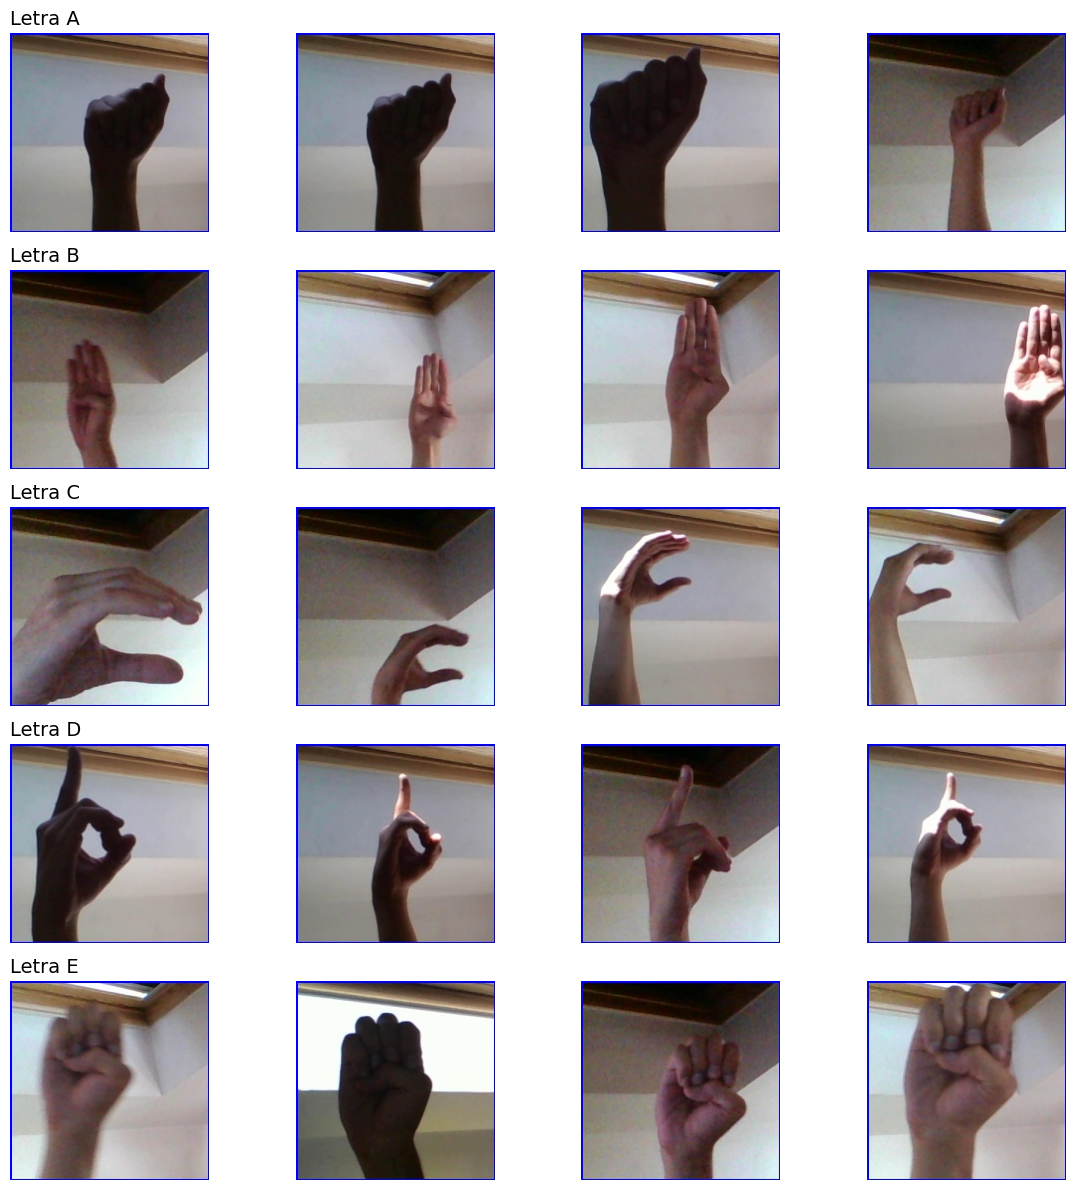

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

letras = ['A', 'B', 'C', 'D', 'E']
muestras_por_letra = 4
base_path = '../data'

fig, axes = plt.subplots(len(letras), muestras_por_letra, figsize=(12, 12))

for i, letra in enumerate(letras):
    letra_path = os.path.join(base_path, letra)
    if os.path.exists(letra_path):
        imagenes = os.listdir(letra_path)[:muestras_por_letra]
        for j, img_name in enumerate(imagenes):
            img_path = os.path.join(letra_path, img_name)
            img = mpimg.imread(img_path)
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(f'Letra {letra}', fontsize=14, loc='left')

plt.tight_layout()
plt.show()

Noté que dentro de cada letra existen cambios importantes en la iluminación y el tipo de fondo. También observé variaciones en la posición y el ángulo de la mano, así como la distancia de la mano a la cámara.

## Análisis exploratorio

In [2]:
from PIL import Image
import os

base_path = '../data'
clases = sorted(os.listdir(base_path))

tamaños = set()
formatos = set()
modos = set()

for clase in clases:
    clase_path = os.path.join(base_path, clase)
    for nombre_img in os.listdir(clase_path)[:5]:
        img = Image.open(os.path.join(clase_path, nombre_img))
        tamaños.add(img.size)
        formatos.add(img.format)
        modos.add(img.mode)

print('Dimensiones encontradas:', tamaños)
print('Formatos encontrados:', formatos)
print('Modos de color encontrados:', modos)

Dimensiones encontradas: {(200, 200)}
Formatos encontrados: {'JPEG'}
Modos de color encontrados: {'RGB'}


Revisé una muestra de imágenes de cada una de las 29 clases y todas tienen la misma resolución de 200x200 píxeles, están en formato JPEG y son a color con los tres canales RGB. No encontré imágenes en escala de grises ni con dimensiones distintas dentro de la submuestra.

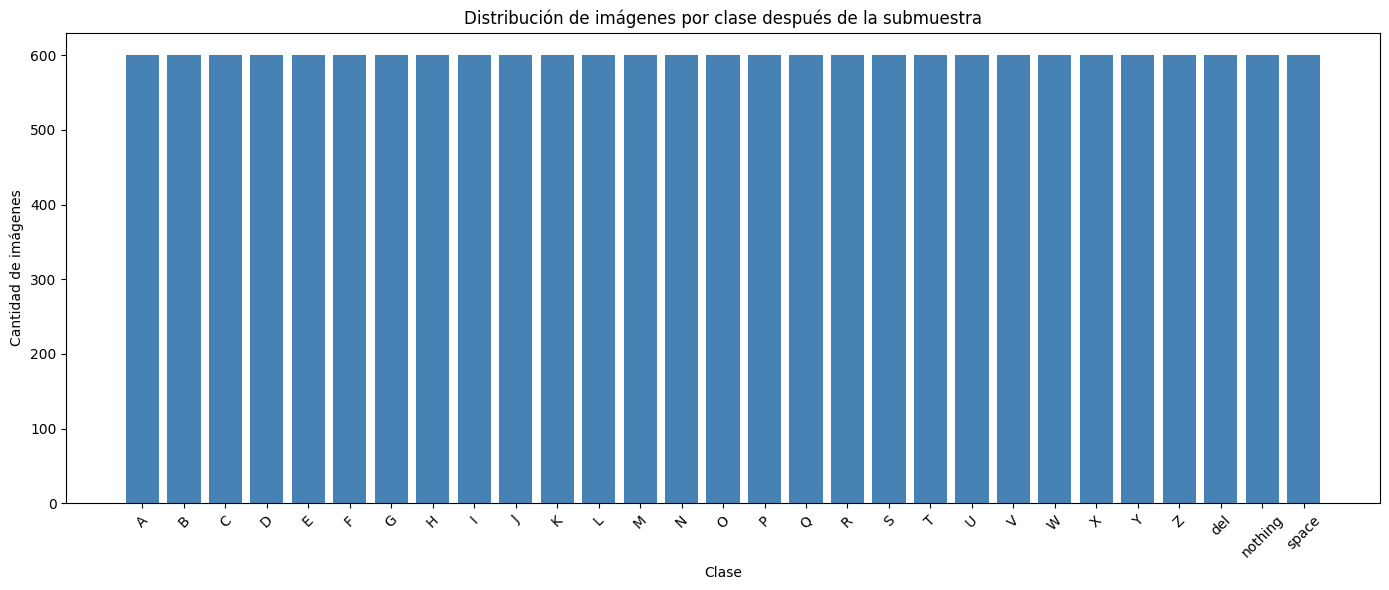

Mínimo de imágenes en una clase: 600
Máximo de imágenes en una clase: 600


In [3]:
conteo_clases = {clase: len(os.listdir(os.path.join(base_path, clase))) for clase in clases}

plt.figure(figsize=(14, 6))
plt.bar(conteo_clases.keys(), conteo_clases.values(), color='steelblue')
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de imágenes por clase después de la submuestra')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Mínimo de imágenes en una clase:', min(conteo_clases.values()))
print('Máximo de imágenes en una clase:', max(conteo_clases.values()))

Todas las 29 clases quedaron con exactamente 600 imágenes, así que el dataset original tenía suficientes imágenes disponibles por letra y la submuestra queda perfectamente balanceada.

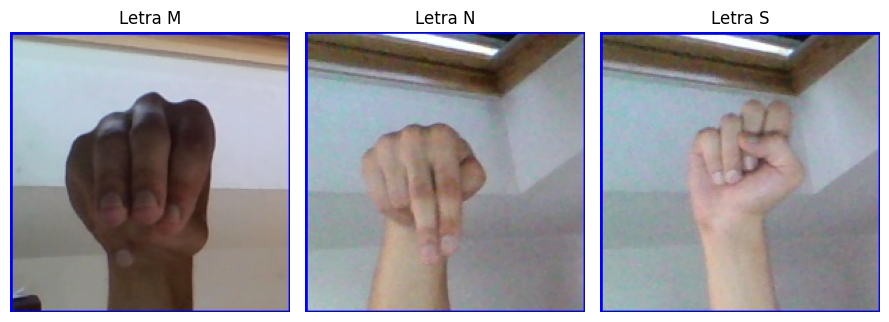

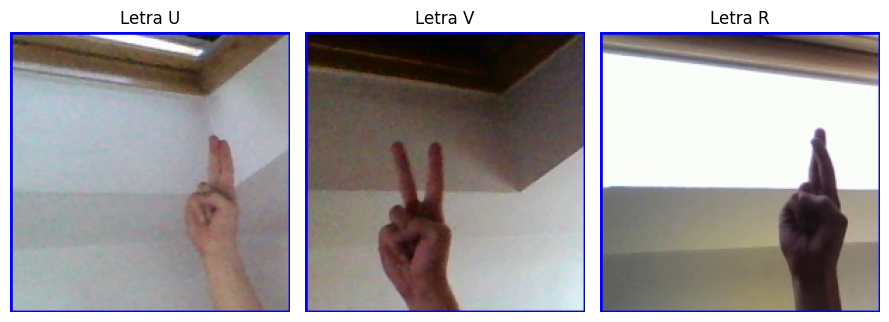

In [4]:
grupos_similares = [['M', 'N', 'S'], ['U', 'V', 'R']]

for grupo in grupos_similares:
    fig, axes = plt.subplots(1, len(grupo), figsize=(9, 4))
    for ax, letra in zip(axes, grupo):
        letra_path = os.path.join(base_path, letra)
        img_name = os.listdir(letra_path)[0]
        img = mpimg.imread(os.path.join(letra_path, img_name))
        ax.imshow(img)
        ax.set_title(f'Letra {letra}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Las letras M, N y S se parecen porque las tres se forman con el puño cerrado y el pulgar escondido debajo de los otros dedos, la diferencia entre ellas es solo la posición exacta del pulgar respecto a los dedos que lo cubren. Algo similar pasa con U, V y R, que se hacen con dos dedos extendidos y varían únicamente en si están juntos, separados o cruzados.

Para el modelo esto puede ser un problema porque son diferencias muy pequeñas en la imagen, casi a nivel de píxeles, y se pueden perder fácilmente con variaciones de ángulo, iluminación o resolución. Es probable que estas letras generen más confusión en la clasificación que otras con formas de mano claramente distintas.

## Preprocesamiento

## Selección de modelos

## Plan de procesamiento de imágenes